# Sentiment Analysis:

## Bibliotecas Necessárias:

In [53]:
import pandas as pd

## pip install scikit-learn
from sklearn.feature_extraction.text import CountVectorizer 

## Separa os dados para treinamento e teste
from sklearn.model_selection import train_test_split

## Regressão Çogística
from sklearn.linear_model import LogisticRegression

## Nuvem de palavras
from wordcloud import WordCloud

import matplotlib.pyplot as plt

import nltk
from nltk import tokenize

import seaborn as sns

!pip install unidecode
import unidecode


## Inicialização dos dados

In [2]:
df = pd.read_csv("./dataset_avaliacoes.csv")

In [3]:
df.head()

,ID_avaliacao,avaliacao,nota,sentimento
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo


In [4]:
df.shape

(15501, 4)

In [5]:
df.value_counts('sentimento')

sentimento
positivo    7890
negativo    7611
dtype: int64

* Exemplo de avaliações:

In [6]:
print("AVALIAÇÃO POSITIVA")

df.avaliacao[0]

AVALIAÇÃO POSITIVA


'Esse smartphone superou minhas expectativas, recomendo'

In [7]:
print("AVALIAÇÃO  NEGATIVA")

df.avaliacao[1]

AVALIAÇÃO  NEGATIVA


'o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo..'

## Transformando textos em dados numéricos:

* Bag Of Words (EXEMPLO DE USO):

In [8]:
texto = ['Comprei um produto ótimo', 'Comprei um produto ruim']

vetorizar = CountVectorizer()

bag = vetorizar.fit_transform(texto)

In [9]:
bag

<2x5 sparse matrix of type '<class 'numpy.int64'>'
	with 8 stored elements in Compressed Sparse Row format>

In [10]:
matriz_esparsa = pd.DataFrame.sparse.from_spmatrix(bag, columns=vetorizar.get_feature_names_out())

In [11]:
matriz_esparsa

,comprei,produto,ruim,um,ótimo
0,1,1,0,1,1
1,1,1,1,1,0


* Bag Of Words (APLICAÇÃO):

In [12]:
# max_features: Pega as palavras com as maiores frequências no dataset para montar a matriz esparsa
vectorizer = CountVectorizer(lowercase=False, max_features=50)

bag_of_words = vectorizer.fit_transform(df.avaliacao)

print(bag_of_words.shape)

(15501, 50)


In [13]:
matriz_esparsa_avaliacoes = pd.DataFrame.sparse.from_spmatrix(bag_of_words, columns=vectorizer.get_feature_names_out())

matriz_esparsa_avaliacoes

,Não,Produto,ainda,antes,as,até,bem,bom,chegou,com,...,qualidade,que,recebi,recomendo,se,sem,tem,um,uma,veio
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,...,1,2,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
15497,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
15498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
15499,0,1,0,1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0


## Separando os dados em conjunto de treino e teste:

In [14]:
X_treino, X_teste, y_treino, y_teste = train_test_split(bag_of_words, df.sentimento, random_state=4978)

In [15]:
# Usando regressão logística
regressao_logistica = LogisticRegression()

regressao_logistica.fit(X_treino, y_treino)

acuracia = regressao_logistica.score(X_teste, y_teste)

print(acuracia)

0.7979876160990712


In [16]:
def classificar_texto(texto, coluna_texto, coluna_classificacao):
    vetorizar = CountVectorizer(lowercase=False, max_features=50)
    bag_of_words = vetorizar.fit_transform(texto[coluna_texto])
    X_treino, X_teste, y_treino, y_teste = train_test_split(bag_of_words, texto[coluna_classificacao], random_state=4978)
    regressao_logistica = LogisticRegression()
    regressao_logistica.fit(X_treino, y_treino)
    acuracia = regressao_logistica.score(X_teste, y_teste)
    return print(f"Acurácia do modelo com '{coluna_texto}': {acuracia * 100:.2f}%")

In [17]:
classificar_texto(df, 'avaliacao', 'sentimento')

Acurácia do modelo com 'avaliacao': 79.80%


## Nuvem de palavras:

In [18]:
all_words = [texto for texto in df.avaliacao]

print(all_words[0])

Esse smartphone superou minhas expectativas, recomendo


In [19]:
all_words_joined = ' '.join([texto for texto in df.avaliacao])

print(all_words_joined)

Esse smartphone superou minhas expectativas, recomendo o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo.. Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra. Atendeu minhas expectativas, só achei a luz ruim, mas nada que dificulte seu funcionamento. Gostei muito, só achei que ficou a desejar a qualidade das fotos. Achei que fosse bem melhor . Comprei o produto e ñ tinha para entrega isso não foi legal!!!!!! o produto pode até ser bom ,mais só posso avalia-lo depois que for feito a troca para eu usa-lo, pois estou esperando a troca ser feita o que recebi veio quebrado já enviei duas reclamações, mas não obtive resposta. recebi o produto quebrado e quero que seja enviado outro. estou no aguardo para saber o que fazer. att. Cármen nao recebi o produto, pois voces nao cumpriram o compromisso firmado de entregar ate hoje 23/05/18. PESSIMA LOGISTICA. Ja solicitei o cancelam

* Nuvem de palavras

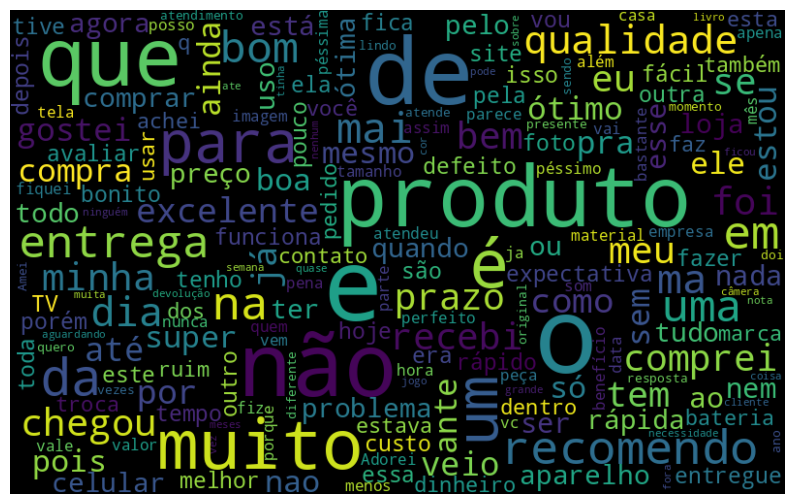

In [20]:
wordcloud = WordCloud(width=800, height=500, max_font_size=110, collocations=False).generate(all_words_joined)
plt.figure(figsize=(10,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

* Função para filtragem da nuvem:

In [21]:
def nuvem_palavras(texto, coluna_texto, sentimento):
    texto_sentimento = texto.query(f"sentimento == '{sentimento}'")[coluna_texto]
    texto_sentimento_unido = ' '.join(texto_sentimento)

    nuvem = WordCloud(width=800, height=500, max_font_size=110, collocations=False).generate(texto_sentimento_unido)

    plt.figure(figsize=(10,7))
    plt.imshow(nuvem, interpolation='bilinear')
    plt.axis('off')
    plt.show()

* Nuvem de palavras (POSITIVAS):

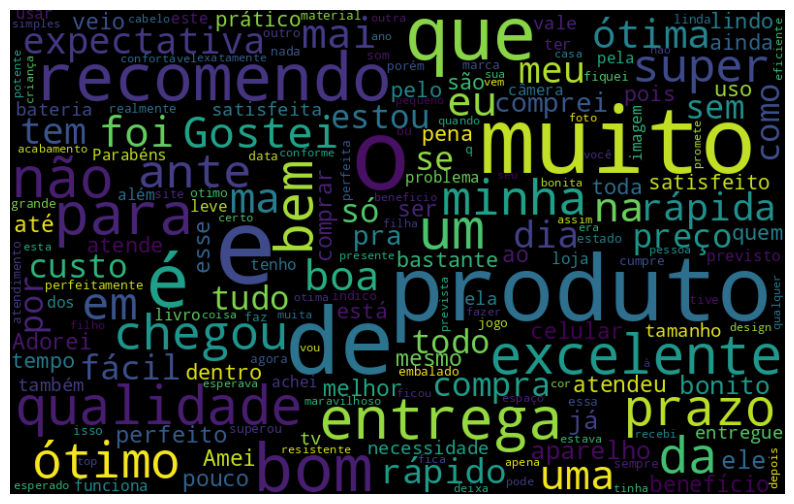

In [22]:
nuvem_palavras(df, 'avaliacao', 'positivo')

* Nuvem de palavras (NEGATIVAS):

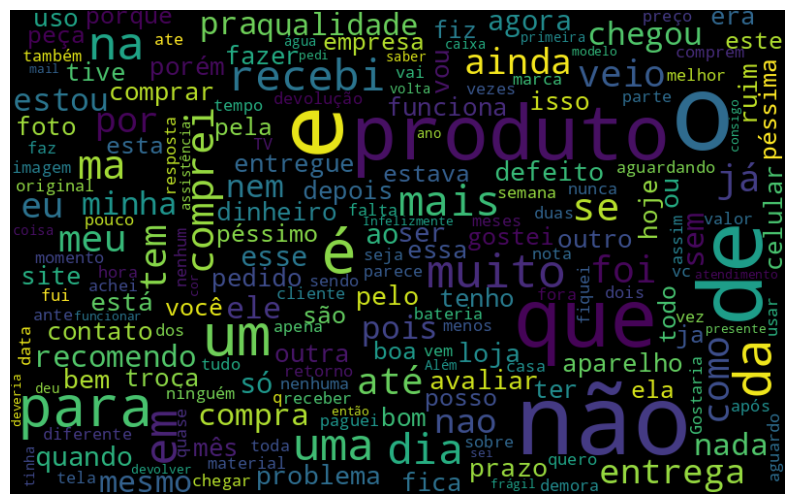

In [23]:
nuvem_palavras(df, 'avaliacao', 'negativo')

## TOKENIZAÇÂO

In [24]:
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     /home/gabrieldantas/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     /home/gabrieldantas/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /home/gabrieldantas/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /home/gabrieldantas/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /home/gabrieldantas/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru

True

* Exemplo de tokenização

In [25]:
frases = ['Um produto bom', 'Um produto ruim']

frequencia = nltk.FreqDist(frases)

frequencia

FreqDist({'Um produto bom': 1, 'Um produto ruim': 1})

In [26]:
frase = 'O produto é excelente e a entrega foi muito rápida!'

token_espaco = tokenize.WhitespaceTokenizer()

token_frase = token_espaco.tokenize(frase)

token_frase

['O',
 'produto',
 'é',
 'excelente',
 'e',
 'a',
 'entrega',
 'foi',
 'muito',
 'rápida!']

* Implementação da tokenização aos dados

In [27]:
token_frase = token_espaco.tokenize(all_words_joined)

token_frase

['Esse',
 'smartphone',
 'superou',
 'minhas',
 'expectativas,',
 'recomendo',
 'o',
 'cheiro',
 'e',
 'muito',
 'desagradavel!!',
 'pra',
 'quem',
 'se',
 'incomoda',
 'nao',
 'recomendoo..',
 'Eu',
 'fiz',
 'a',
 'compra',
 'a',
 'loja',
 'não',
 'entregou',
 'o',
 'produto,',
 'a',
 'compra',
 'foi',
 'feita',
 'no',
 'cartão',
 'de',
 'credito',
 'e',
 'ate',
 'o',
 'momento',
 'a',
 'loja',
 'também',
 'nao',
 'me',
 'devolveu',
 'o',
 'valor',
 'da',
 'compra.',
 'Atendeu',
 'minhas',
 'expectativas,',
 'só',
 'achei',
 'a',
 'luz',
 'ruim,',
 'mas',
 'nada',
 'que',
 'dificulte',
 'seu',
 'funcionamento.',
 'Gostei',
 'muito,',
 'só',
 'achei',
 'que',
 'ficou',
 'a',
 'desejar',
 'a',
 'qualidade',
 'das',
 'fotos.',
 'Achei',
 'que',
 'fosse',
 'bem',
 'melhor',
 '.',
 'Comprei',
 'o',
 'produto',
 'e',
 'ñ',
 'tinha',
 'para',
 'entrega',
 'isso',
 'não',
 'foi',
 'legal!!!!!!',
 'o',
 'produto',
 'pode',
 'até',
 'ser',
 'bom',
 ',mais',
 'só',
 'posso',
 'avalia-lo',
 'depo

In [28]:
frequencia = nltk.FreqDist(token_frase)
frequencia

FreqDist({'e': 11813, 'o': 10865, 'de': 10280, 'a': 8873, 'que': 7657, 'não': 7286, 'é': 4786, 'produto': 4765, 'com': 4641, 'do': 4583, ...})

In [29]:
df_frequencia = pd.DataFrame({
    'Palavra': list(frequencia.keys()),
    'Frequência': list(frequencia.values())
})

df_frequencia.head()

,Palavra,Frequência
0,Esse,101
1,smartphone,33
2,superou,90
3,minhas,533
4,"expectativas,",79


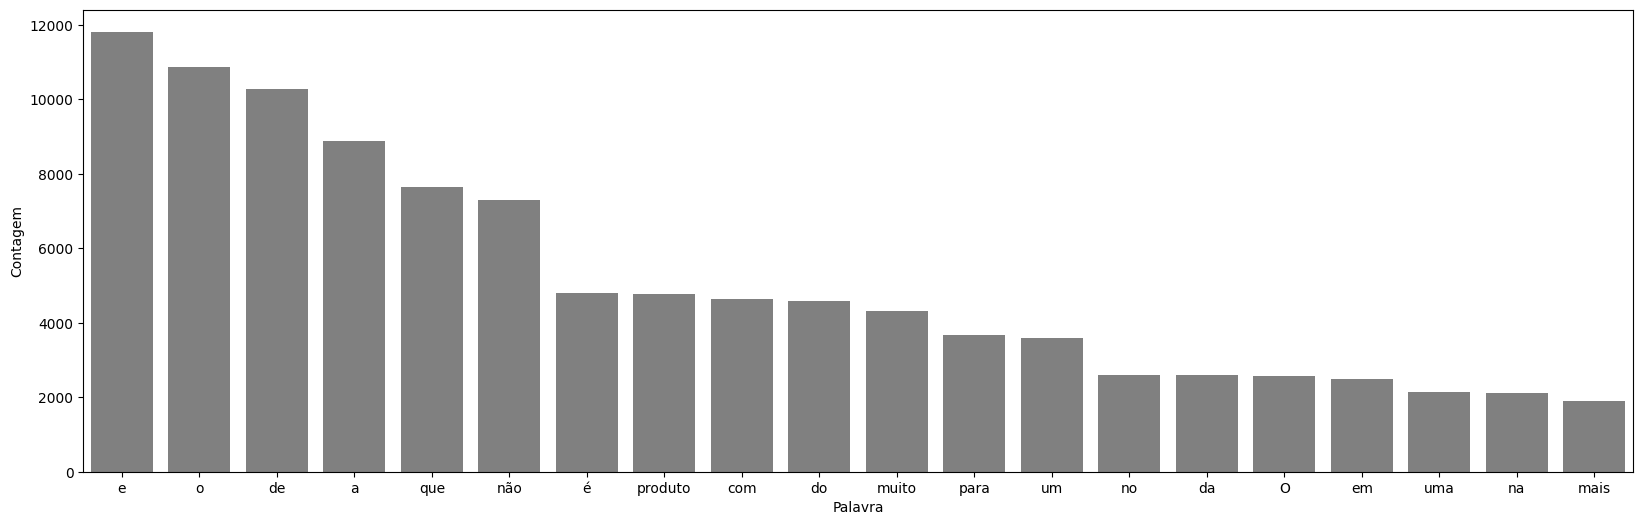

In [30]:
plt.figure(figsize=(20, 6))
ax = sns.barplot(data=df_frequencia.nlargest(columns='Frequência', n=20), x='Palavra', y='Frequência', color='gray')
ax.set(ylabel='Contagem')
plt.show()


* Função para visualizar a frequência de palavras em um dataset

In [31]:
def grafico_frequencia(texto, coluna_texto, quantidade):  
    # Juntando todos os textos em uma única string
    todas_palavras = ' '.join([texto for texto in texto[coluna_texto]])
    
    # Calculando a frequência das palavras
    token_espaco = tokenize.WhitespaceTokenizer()
    frequencia = nltk.FreqDist(token_espaco.tokenize(todas_palavras))
    
    # Criando um DataFrame com as palavras e suas frequências
    df_frequencia = pd.DataFrame({"Palavra": list(frequencia.keys()),
                                  "Frequência": list(frequencia.values())})
    
    # Selecionando as palavras mais frequentes
    df_frequencia = df_frequencia.nlargest(columns="Frequência", n=quantidade)
    
    # Criando o gráfico de barras
    plt.figure(figsize=(20,6))
    ax = sns.barplot(data=df_frequencia, x="Palavra", y="Frequência", color='gray')
    ax.set(ylabel="Contagem")
    
    # Exibindo o gráfico
    plt.show()

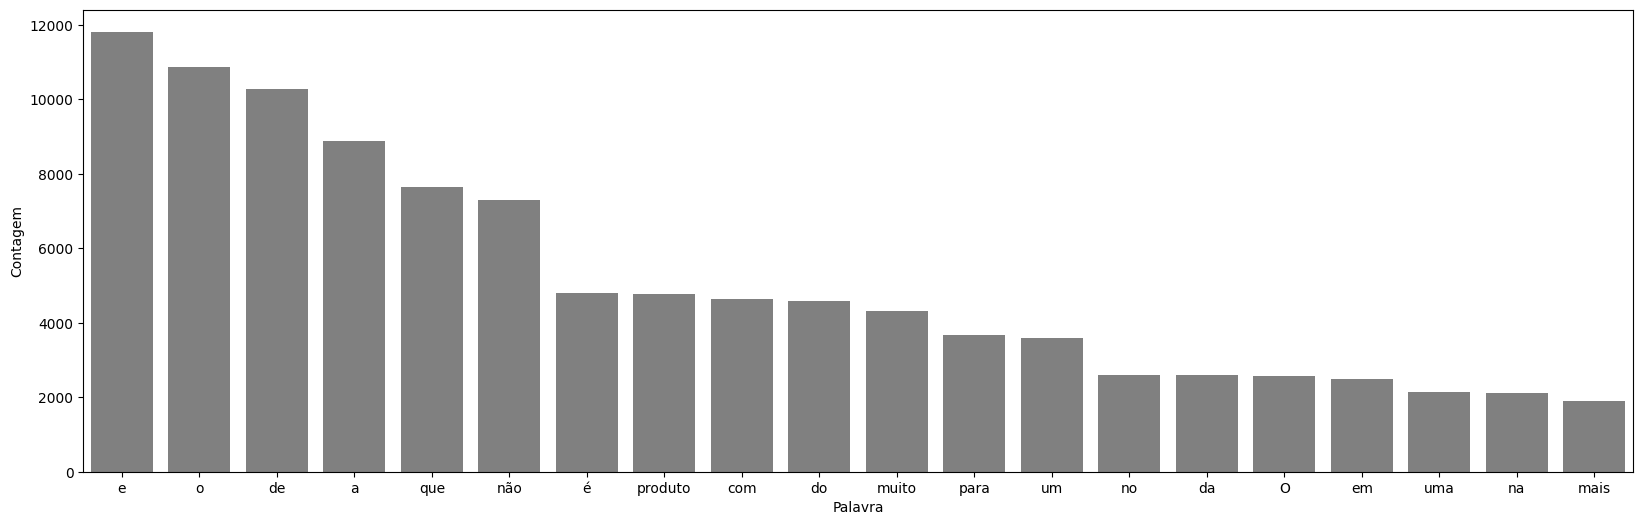

In [32]:
grafico_frequencia(df, 'avaliacao', 20)

## Limpando e normalizando dados textuais:


### Rmovendo Stop Words

In [33]:
palavras_irrelevantes = nltk.corpus.stopwords.words('portuguese')

palavras_irrelevantes

['a',
 'à',
 'ao',
 'aos',
 'aquela',
 'aquelas',
 'aquele',
 'aqueles',
 'aquilo',
 'as',
 'às',
 'até',
 'com',
 'como',
 'da',
 'das',
 'de',
 'dela',
 'delas',
 'dele',
 'deles',
 'depois',
 'do',
 'dos',
 'e',
 'é',
 'ela',
 'elas',
 'ele',
 'eles',
 'em',
 'entre',
 'era',
 'eram',
 'éramos',
 'essa',
 'essas',
 'esse',
 'esses',
 'esta',
 'está',
 'estamos',
 'estão',
 'estar',
 'estas',
 'estava',
 'estavam',
 'estávamos',
 'este',
 'esteja',
 'estejam',
 'estejamos',
 'estes',
 'esteve',
 'estive',
 'estivemos',
 'estiver',
 'estivera',
 'estiveram',
 'estivéramos',
 'estiverem',
 'estivermos',
 'estivesse',
 'estivessem',
 'estivéssemos',
 'estou',
 'eu',
 'foi',
 'fomos',
 'for',
 'fora',
 'foram',
 'fôramos',
 'forem',
 'formos',
 'fosse',
 'fossem',
 'fôssemos',
 'fui',
 'há',
 'haja',
 'hajam',
 'hajamos',
 'hão',
 'havemos',
 'haver',
 'hei',
 'houve',
 'houvemos',
 'houver',
 'houvera',
 'houverá',
 'houveram',
 'houvéramos',
 'houverão',
 'houverei',
 'houverem',
 'hou

In [34]:
frase_processada = []

for opiniao in df.avaliacao:
    palavras_texto = token_espaco.tokenize(opiniao)
    nova_frase = [palavra for palavra in palavras_texto if palavra not in palavras_irrelevantes]
    frase_processada.append(' '.join(nova_frase))

df['tratamento_1'] = frase_processada

df.head()

,ID_avaliacao,avaliacao,nota,sentimento,tratamento_1
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"Esse smartphone superou expectativas, recomendo"
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,cheiro desagradavel!! pra incomoda nao recomen...
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"Eu fiz compra loja entregou produto, compra fe..."
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"Atendeu expectativas, achei luz ruim, nada dif..."
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"Gostei muito, achei ficou desejar qualidade fo..."


In [35]:
print("TEXTO:                ", df['avaliacao'][0])
print("TEXTO SEM STOP WORDS: ", df['tratamento_1'][0])

TEXTO:                 Esse smartphone superou minhas expectativas, recomendo
TEXTO SEM STOP WORDS:  Esse smartphone superou expectativas, recomendo


In [36]:
classificar_texto(df, 'tratamento_1', 'sentimento')

Acurácia do modelo com 'tratamento_1': 81.14%


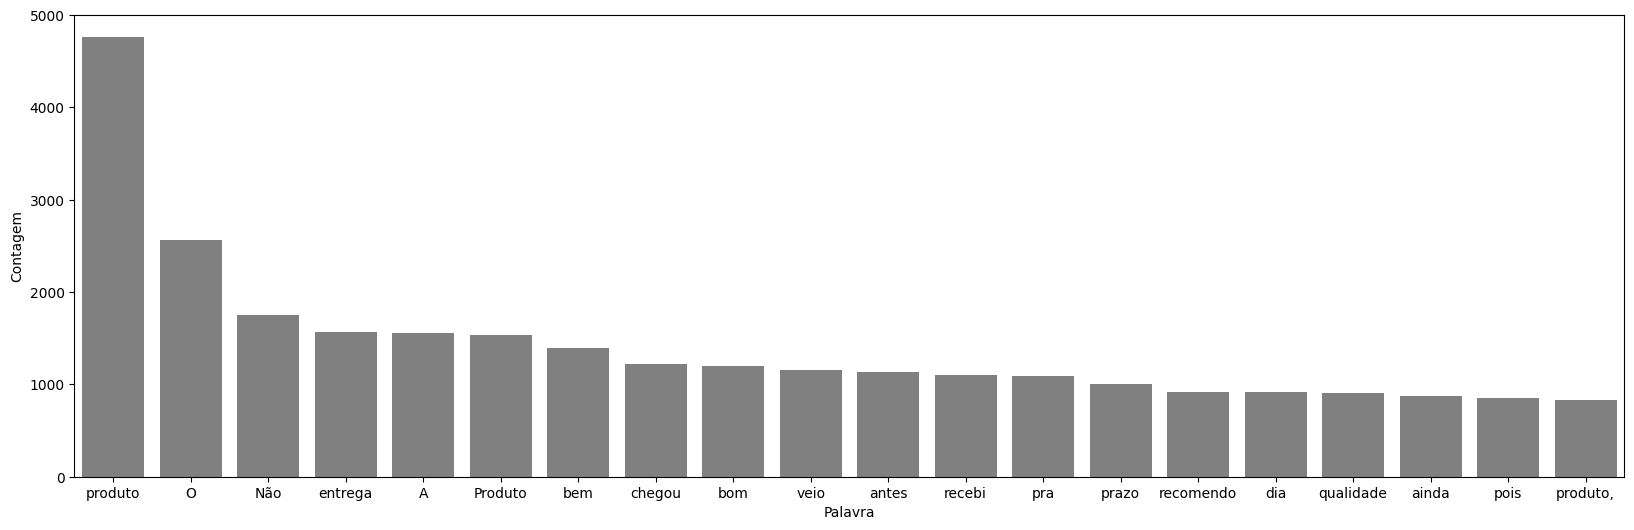

In [37]:
grafico_frequencia(df, 'tratamento_1', 20)

### Removendo Pontuacao:

In [39]:
frase = 'Esse smartphone superou expectativas, recomendo'

token_pontuacao = tokenize.WordPunctTokenizer()

token_frase_punct = token_pontuacao.tokenize(frase)

token_frase_punct

['Esse', 'smartphone', 'superou', 'expectativas', ',', 'recomendo']

In [43]:
frase_processada_punct = []

for opiniao in df['tratamento_1']:
    palavras_texto = token_pontuacao.tokenize(opiniao)
    nova_frase = [palavra for palavra in palavras_texto if palavra.isalpha() and palavra not in palavras_irrelevantes]
    frase_processada_punct.append(' '.join(nova_frase))

df['tratamento_2'] = frase_processada_punct

In [44]:
df.head()

,ID_avaliacao,avaliacao,nota,sentimento,tratamento_1,tratamento_2
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"Esse smartphone superou expectativas, recomendo",Esse smartphone superou expectativas recomendo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,cheiro desagradavel!! pra incomoda nao recomen...,cheiro desagradavel pra incomoda nao recomendoo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"Eu fiz compra loja entregou produto, compra fe...",Eu fiz compra loja entregou produto compra fei...
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"Atendeu expectativas, achei luz ruim, nada dif...",Atendeu expectativas achei luz ruim nada dific...
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"Gostei muito, achei ficou desejar qualidade fo...",Gostei achei ficou desejar qualidade fotos Ach...


In [70]:
print("TEXTO:        ", df['avaliacao'][0])
print("TRATAMENTO 1: ", df['tratamento_1'][0])
print("TRATAMENTO 2: ", df['tratamento_2'][0])


TEXTO:         Esse smartphone superou minhas expectativas, recomendo
TRATAMENTO 1:  Esse smartphone superou expectativas, recomendo
TRATAMENTO 2:  Esse smartphone superou expectativas recomendo


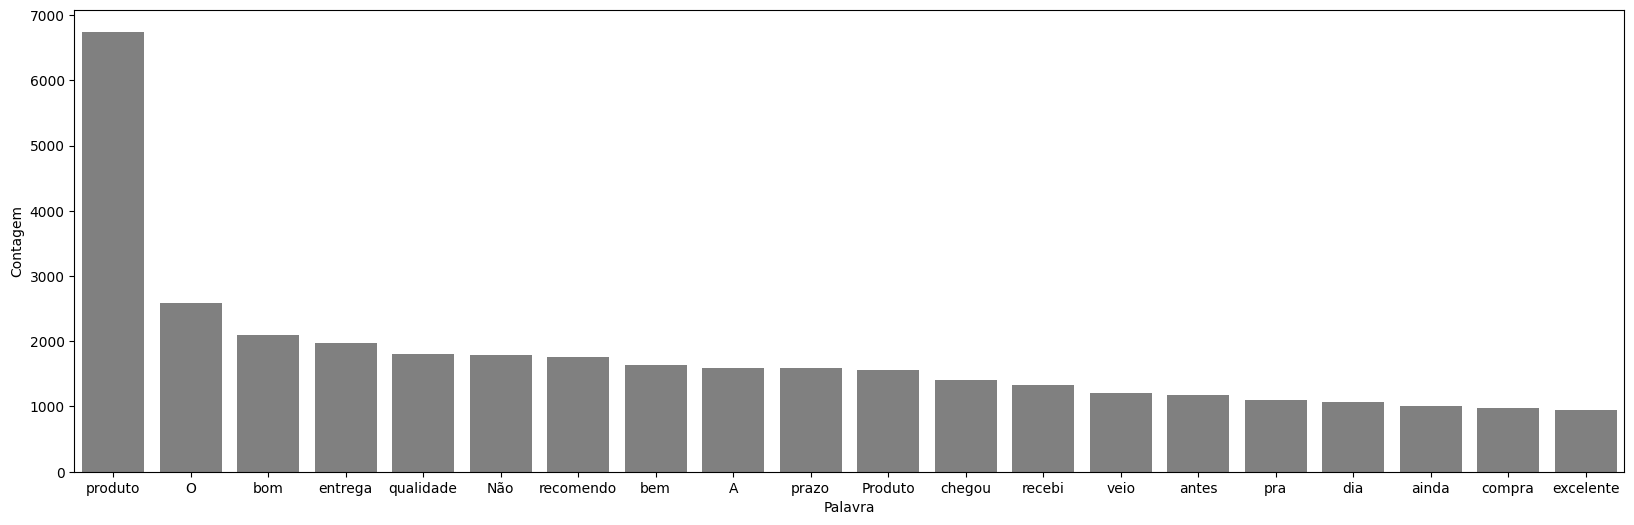

In [48]:
grafico_frequencia(df, 'tratamento_2', 20)

In [99]:
classificar_texto(df, 'tratamento_2', 'sentimento')

Acurácia do modelo com 'tratamento_2': 81.14%


### Removendo acentuação:

In [73]:
# Import unicode

frase = 'Um aparelho ótima performance preço bem menor outros aparelhos marcas conhecidas performance semelhante.'

teste = unidecode.unidecode(frase)

teste

'Um aparelho otima performance preco bem menor outros aparelhos marcas conhecidas performance semelhante.'

In [75]:
sem_acentos = [unidecode.unidecode(texto) for texto in df['tratamento_2']]

In [76]:
stop_words_sem_acentos = [unidecode.unidecode(texto) for texto in palavras_irrelevantes]

In [80]:
df['tratamento_3'] = sem_acentos

frase_processada_acentos = []

for opiniao in df['tratamento_3']:
    palavras_texto = token_pontuacao.tokenize(opiniao)
    nova_frase = [palavra for palavra in palavras_texto if palavra not in stop_words_sem_acentos]
    frase_processada_acentos.append(' '.join(nova_frase))

df['tratamento_3'] = frase_processada_acentos

In [81]:
df.head()

,ID_avaliacao,avaliacao,nota,sentimento,tratamento_1,tratamento_2,tratamento_3
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"Esse smartphone superou expectativas, recomendo",Esse smartphone superou expectativas recomendo,Esse smartphone superou expectativas recomendo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,cheiro desagradavel!! pra incomoda nao recomen...,cheiro desagradavel pra incomoda nao recomendoo,cheiro desagradavel pra incomoda recomendoo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"Eu fiz compra loja entregou produto, compra fe...",Eu fiz compra loja entregou produto compra fei...,Eu fiz compra loja entregou produto compra fei...
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"Atendeu expectativas, achei luz ruim, nada dif...",Atendeu expectativas achei luz ruim nada dific...,Atendeu expectativas achei luz ruim nada dific...
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"Gostei muito, achei ficou desejar qualidade fo...",Gostei achei ficou desejar qualidade fotos Ach...,Gostei achei ficou desejar qualidade fotos Ach...


In [90]:
print("TEXTO:        ", df['avaliacao'][70])
print("TRATAMENTO 1: ", df['tratamento_1'][70])
print("TRATAMENTO 2: ", df['tratamento_2'][70])
print("TRATAMENTO 3: ", df['tratamento_3'][70])

TEXTO:         100%. Melhor compra que já fiz nos últimos tempos. Produto barato e útil. Produto robusto e leve. O teclado proporciona uma digitação confortável e o mouse é preciso. O teclado e o mouse usam apenas um receptor, economizando o número de portas USB do computador. Me livrei do incomodo dos fios e meu espaço de trabalho ficou mais limpo e harmonioso. Ademais, o tudo me parece bastante durável. 100% safisfeito. Recomendo à todos.
TRATAMENTO 1:  100%. Melhor compra fiz últimos tempos. Produto barato útil. Produto robusto leve. O teclado proporciona digitação confortável mouse preciso. O teclado mouse usam apenas receptor, economizando número portas USB computador. Me livrei incomodo fios espaço trabalho ficou limpo harmonioso. Ademais, tudo parece bastante durável. 100% safisfeito. Recomendo todos.
TRATAMENTO 2:  Melhor compra fiz últimos tempos Produto barato útil Produto robusto leve O teclado proporciona digitação confortável mouse preciso O teclado mouse usam apenas recep

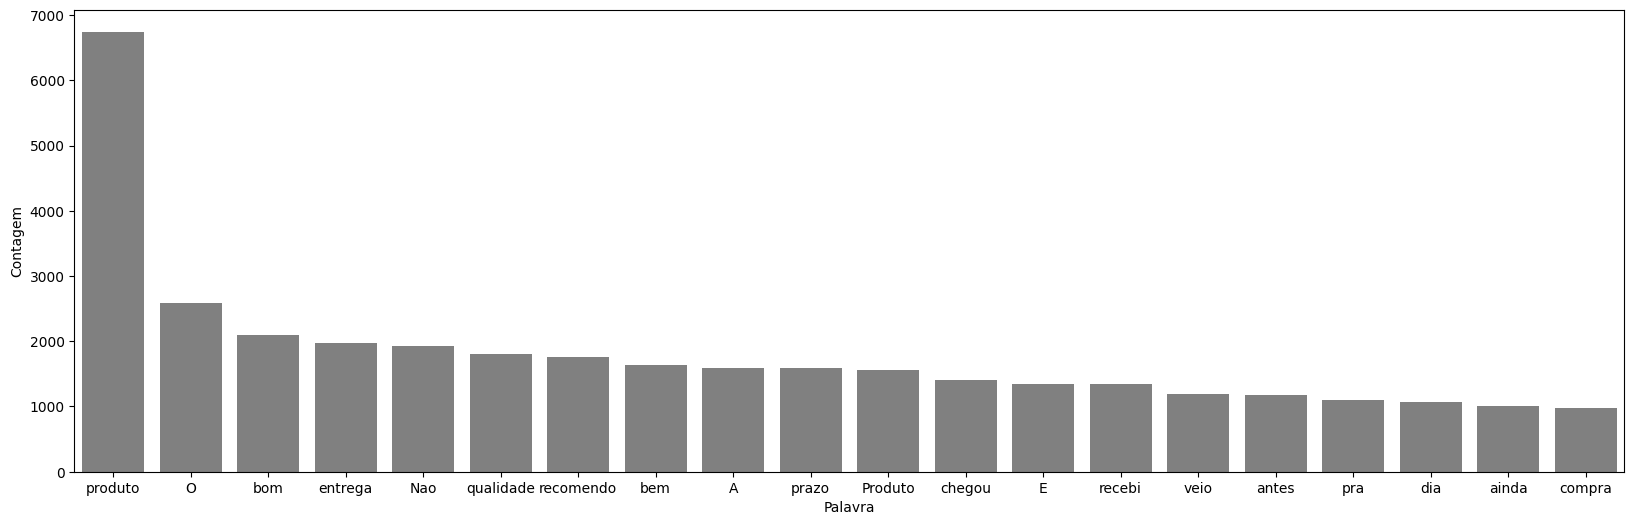

In [91]:
grafico_frequencia(df, 'tratamento_3', 20)

In [100]:
classificar_texto(df, 'tratamento_3', 'sentimento')

Acurácia do modelo com 'tratamento_3': 81.99%


### Uniformizando o texto

In [93]:
frase = 'Bom produto otimo custo beneficio Recomendo Confortavel bem acabado'

frase.lower()

'bom produto otimo custo beneficio recomendo confortavel bem acabado'

In [101]:
frase_processada_normalizada = []

for opiniao in df['tratamento_3']:
    opiniao = opiniao.lower()
    palavras_texto = token_pontuacao.tokenize(opiniao)
    nova_frase = [palavra for palavra in palavras_texto if palavra not in stop_words_sem_acentos]
    frase_processada_normalizada.append(' '.join(nova_frase))

df['tratamento_4'] = frase_processada_normalizada

In [102]:
df.head()

,ID_avaliacao,avaliacao,nota,sentimento,tratamento_1,tratamento_2,tratamento_3,tratamento_4
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"Esse smartphone superou expectativas, recomendo",Esse smartphone superou expectativas recomendo,Esse smartphone superou expectativas recomendo,smartphone superou expectativas recomendo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,cheiro desagradavel!! pra incomoda nao recomen...,cheiro desagradavel pra incomoda nao recomendoo,cheiro desagradavel pra incomoda recomendoo,cheiro desagradavel pra incomoda recomendoo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"Eu fiz compra loja entregou produto, compra fe...",Eu fiz compra loja entregou produto compra fei...,Eu fiz compra loja entregou produto compra fei...,fiz compra loja entregou produto compra feita ...
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"Atendeu expectativas, achei luz ruim, nada dif...",Atendeu expectativas achei luz ruim nada dific...,Atendeu expectativas achei luz ruim nada dific...,atendeu expectativas achei luz ruim nada dific...
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"Gostei muito, achei ficou desejar qualidade fo...",Gostei achei ficou desejar qualidade fotos Ach...,Gostei achei ficou desejar qualidade fotos Ach...,gostei achei ficou desejar qualidade fotos ach...


In [105]:
print(df['tratamento_3'][70])
print(df['tratamento_4'][70])

Melhor compra fiz ultimos tempos Produto barato util Produto robusto leve O teclado proporciona digitacao confortavel mouse preciso O teclado mouse usam apenas receptor economizando numero portas USB computador Me livrei incomodo fios espaco trabalho ficou limpo harmonioso Ademais tudo parece bastante duravel safisfeito Recomendo todos
melhor compra fiz ultimos tempos produto barato util produto robusto leve teclado proporciona digitacao confortavel mouse preciso teclado mouse usam apenas receptor economizando numero portas usb computador livrei incomodo fios espaco trabalho ficou limpo harmonioso ademais tudo parece bastante duravel safisfeito recomendo todos


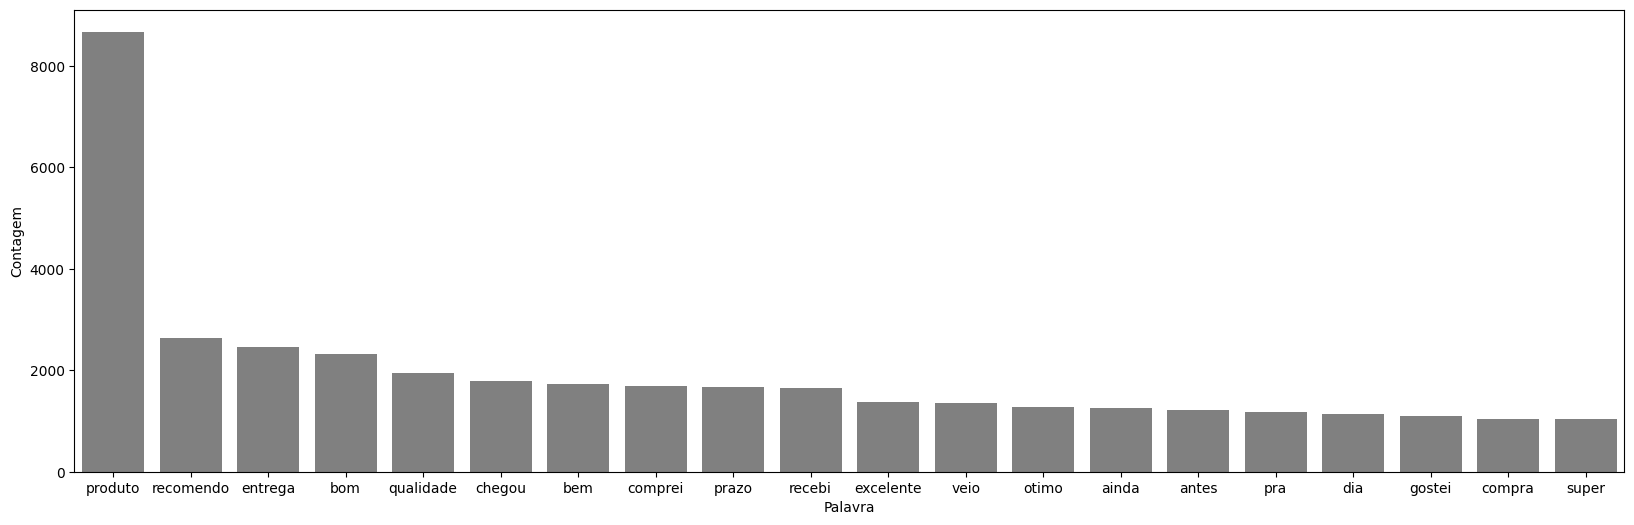

In [107]:
grafico_frequencia(df, 'tratamento_4', 20)

In [108]:
classificar_texto(df, 'tratamento_4', 'sentimento')

Acurácia do modelo com 'tratamento_4': 83.77%


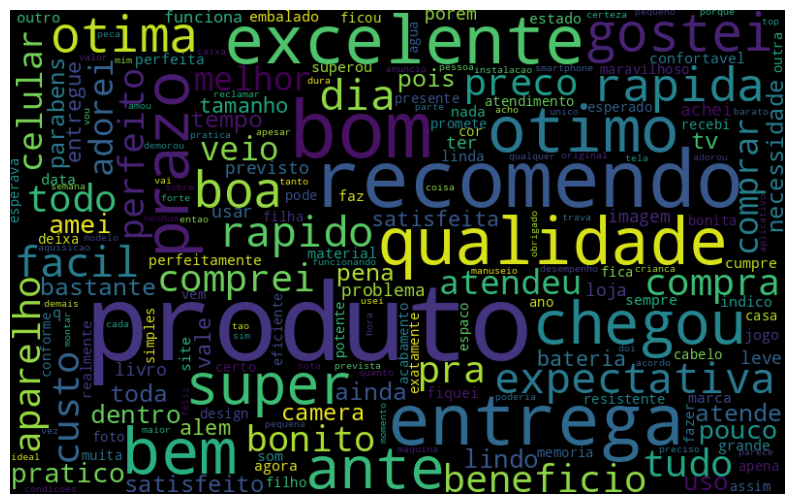

In [109]:
nuvem_palavras(df, 'tratamento_4', 'positivo')

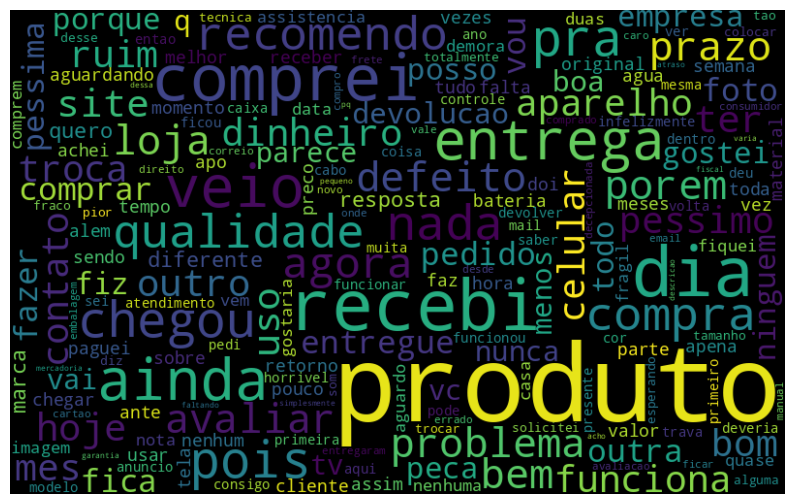

In [110]:
nuvem_palavras(df, 'tratamento_4', 'negativo')